**Smoothing Images**

**2D Convolution (Image Filtering)**

As for one-dimensional signals, images also can be filtered with various low-pass filters (LPF), high-pass filters (HPF), etc. A LPF helps in removing noise, or blurring the image. A HPF filters helps in finding edges in an image. OpenCV's `cv2.filter2D()` helps to do that.


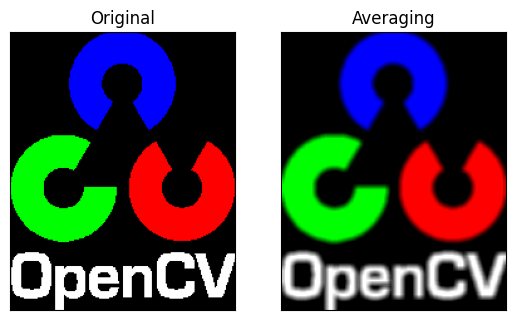

In [3]:
import cv2
import numpy as np 
import matplotlib.pyplot as plt 

img = cv2.imread('opencv-logo-white.png')
# cv2.imshow('img', img)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

kernel = np.ones((5,5), np.float32)/25 # 5x5 kernel divided by 25
dst = cv2.filter2D(img, -1, kernel)
plt.subplot(121), plt.imshow(img), plt.title('Original')
plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(dst), plt.title('Averaging')
plt.xticks([]), plt.yticks([])
plt.show()


In another way we can do blurring

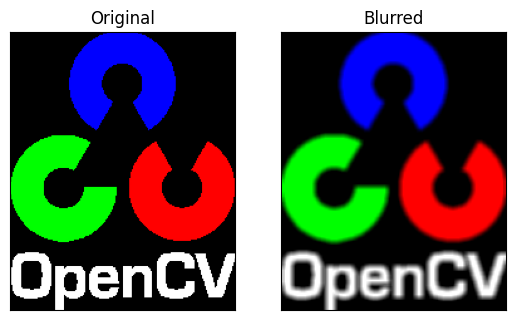

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('opencv-logo-white.png')
dst = cv2.blur(img, (5,5))
plt.subplot(121), plt.imshow(img), plt.title('Original')
plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(dst), plt.title('Blurred')
plt.xticks([]), plt.yticks([])
plt.show()

Using **Gaussian Filtering**

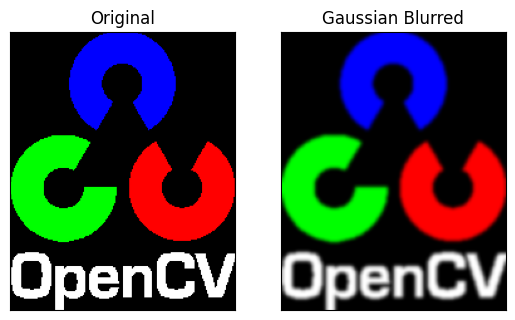

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('opencv-logo-white.png')
dst = cv2.GaussianBlur(img, (7,7),0)
plt.subplot(121), plt.imshow(img), plt.title('Original')
plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(dst), plt.title('Gaussian Blurred')
plt.xticks([]), plt.yticks([])
plt.show()

Adding **Gaussian Noise**

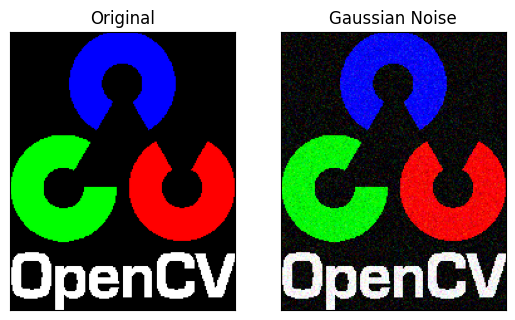

In [9]:
import cv2
import numpy as np 
import matplotlib.pyplot as plt

img = cv2.imread('opencv-logo-white.png')

# Adding gaussian noise with mean 0, standard deviation 25
mean = 0
std = 25
gaussian_noise = np.random.normal(mean, std, img.shape).astype('int16')

# Adding gaussian noise into original image
noisy_image = img.astype('int16') + gaussian_noise

# Clipping the values to stay between 0, 255 and reback to unit8
noisy_image  =np.clip(noisy_image, 0, 255).astype('uint8')

plt.subplot(121), plt.imshow(img), plt.title('Original')
plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(noisy_image), plt.title('Gaussian Noise')
plt.xticks([]), plt.yticks([])
plt.show()

**Salt-and-Pepper** noise

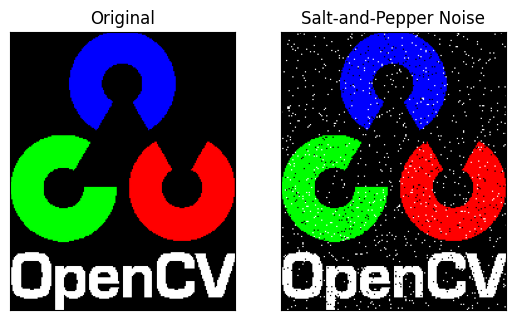

In [10]:
import cv2
import numpy as np
import random

img = cv2.imread('opencv-logo-white.png')
noisy_image = img.copy()

# Define the percentage of pixels to corrupt (e.g., 5%)
probability = 0.05

# Total number of pixels to change
num_pixels = int(probability * img.size / img.shape[2])

# Add "Salt" (White pixels)
for _ in range(num_pixels // 2):
    y = random.randint(0, img.shape[0] - 1)
    x = random.randint(0, img.shape[1] - 1)
    noisy_image[y, x] = [255, 255, 255]

# Add "Pepper" (Black pixels)
for _ in range(num_pixels // 2):
    y = random.randint(0, img.shape[0] - 1)
    x = random.randint(0, img.shape[1] - 1)
    noisy_image[y, x] = [0, 0, 0]

plt.subplot(121), plt.imshow(img), plt.title('Original')
plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(noisy_image), plt.title('Salt-and-Pepper Noise')
plt.xticks([]), plt.yticks([])
plt.show()

Removing **Salt-and-Pepper** noise with **Median Filtering**

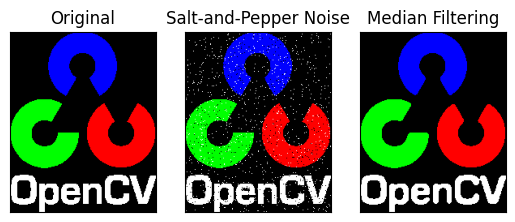

In [13]:
import cv2
import numpy as np
import random

img = cv2.imread('opencv-logo-white.png')
noisy_image = img.copy()

# Define the percentage of pixels to corrupt (e.g., 5%)
probability = 0.05

# Total number of pixels to change
num_pixels = int(probability * img.size / img.shape[2])

# Add "Salt" (White pixels)
for _ in range(num_pixels // 2):
    y = random.randint(0, img.shape[0] - 1)
    x = random.randint(0, img.shape[1] - 1)
    noisy_image[y, x] = [255, 255, 255]

# Add "Pepper" (Black pixels)
for _ in range(num_pixels // 2):
    y = random.randint(0, img.shape[0] - 1)
    x = random.randint(0, img.shape[1] - 1)
    noisy_image[y, x] = [0, 0, 0]

# plt.subplot(121), plt.imshow(img), plt.title('Original')
# plt.xticks([]), plt.yticks([])
# plt.subplot(122), plt.imshow(noisy_image), plt.title('Salt-and-Pepper Noise')
# plt.xticks([]), plt.yticks([])
# plt.show()

median = cv2.medianBlur(img, 5) # Median Filtering
plt.subplot(131), plt.imshow(img), plt.title('Original')
plt.xticks([]), plt.yticks([])
plt.subplot(132), plt.imshow(noisy_image), plt.title('Salt-and-Pepper Noise')
plt.xticks([]), plt.yticks([])
plt.subplot(133), plt.imshow(median), plt.title('Median Filtering')
plt.xticks([]), plt.yticks([])
plt.show()

**Excercise**

In [13]:
import cv2
import numpy as np 
import matplotlib.pyplot as plt 
import random


img = cv2.imread('dogs.jpg')
resized_img = cv2.resize(img, (640, 480)) # will be working in this img format
cv2.imshow('img', resized_img)
cv2.waitKey(0)
cv2.destroyAllWindows()

# Additing gaussian noise
mean = 0
std = 50
gaussian_noise  = np.random.normal(mean, std, resized_img.shape).astype('int16')
noisy_img = resized_img.astype('int16') + gaussian_noise
gaussian_noisy_img = np.clip(noisy_img, 0, 255).astype('uint8')

# plt.subplot(121), plt.imshow(resized_img), plt.title('Original')
# plt.xticks([]), plt.yticks([])
# plt.subplot(122), plt.imshow(gaussian_noisy_img), plt.title('Gaussian Noise')
# plt.xticks([]), plt.yticks([])
# plt.show()

cv2.imshow('Gaussian Noisy Image', gaussian_noisy_img)
cv2.waitKey(0)
cv2.destroyAllWindows()



# Adding salt-and-pepper noise
salt_pepper_noisy_img = resized_img.copy()
probability = 0.5
num_pixels = int(probability * resized_img.size / resized_img.shape[2])
for _ in range(num_pixels // 2):
    y = random.randint(0, resized_img.shape[0] - 1)
    x = random.randint(0, resized_img.shape[1] - 1)
    salt_pepper_noisy_img[y, x] = [255, 255, 255]

for _ in range(num_pixels // 2):
    y = random.randint(0, resized_img.shape[0] - 1)
    x = random.randint(0, resized_img.shape[1] - 1)
    salt_pepper_noisy_img[y, x] = [0, 0, 0]


cv2.imshow('Salt-and-Pepper Noisy Image',salt_pepper_noisy_img)
cv2.waitKey(0)
cv2.destroyAllWindows()

**Removing noise from gaussian noisy image using box, gaussian, median and bilatral filtering**

In [ ]:
# Box Filtering
kernel = np.ones((5, 5), np.float32)/25 # 5x5 kernel divided by 25
box_dst = cv2.filter2D(gaussian_noisy_img, -1, kernel)

cv2.imshow('Gaussian Noise Image', gaussian_noisy_img)
cv2.waitKey(0)
cv2.destroyAllWindows()

cv2.imshow('Box Filtering', box_dst)
cv2.waitKey(0)
cv2.destroyAllWindows()

# Gaussian Filtering
gaussian_dst = cv2.GaussianBlur(gaussian_noisy_img, (5,5), 0)
cv2.imshow('Gaussian Filtering', gaussian_dst)
cv2.waitKey(0)
cv2.destroyAllWindows()

# Median Filtering
median_dst = cv2.medianBlur(gaussian_noisy_img, 5)
cv2.imshow('Median Filtering', median_dst)
cv2.waitKey(0)
cv2.destroyAllWindows()

# Bilatral Filtering
bilatral_dst = cv2.bilateralFilter(gaussian_noisy_img, 9, 75, 75)
cv2.imshow('Bilatral Filtering', bilatral_dst)
cv2.waitKey(0)
cv2.destroyAllWindows()
